# Практика 8: Реализация GNN с вниманием (GAT)

Добавим механизм внимания в GNN. Используем `GATConv`, который взвешивает соседние узлы с учётом их важности. Переобучаем модель на `Cora`, сравниваем качество классификации узлов с `GCNConv`. Визуализируем полученные эмбеддинги с помощью `t-SN`E, чтобы увидеть, как сеть группирует похожие узлы. Экспериментируем с разными числами голов внимания, анализируем влияние на результаты.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.nn import GCNConv, GATConv

from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [3]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
dataset = Planetoid(root="./data/Planetoid", name="Cora", transform=NormalizeFeatures())
data = dataset[0].to(device)

In [5]:
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index, return_embeddings=False):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        embeddings = x

        x = self.conv2(x, edge_index)

        if return_embeddings:
            return x, embeddings
        return x

In [6]:
class GAT(nn.Module):
    def __init__(
        self,
        in_channels,
        hidden_channels,
        out_channels,
        heads=8,
        dropout=0.6
    ):
        super().__init__()
        self.dropout = dropout

        self.gat1 = GATConv(
            in_channels=in_channels,
            out_channels=hidden_channels,
            heads=heads,
            dropout=dropout
        )

        self.gat2 = GATConv(
            in_channels=hidden_channels * heads,
            out_channels=out_channels,
            heads=1,
            concat=False,
            dropout=dropout
        )

    def forward(self, x, edge_index, return_embeddings=False):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        embeddings = x

        x = self.gat2(x, edge_index)

        if return_embeddings:
            return x, embeddings
        return x

In [7]:
def train_step(model, data, optimizer, criterion):
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])

    loss.backward()
    optimizer.step()

    return loss.item()


@torch.no_grad()
def evaluate(model, data, mask):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

    correct = (pred[mask] == data.y[mask]).sum().item()
    total = int(mask.sum())
    acc = correct / total

    return acc, pred, out

In [8]:
def fit_model(model, data, num_epochs=200, lr=0.005, weight_decay=5e-4, verbose=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    train_accuracies = []
    val_accuracies = []
    test_accuracies = []

    best_val_acc = 0.0
    best_state_dict = None

    for epoch in range(1, num_epochs + 1):
        loss = train_step(model, data, optimizer, criterion)

        train_acc, _, _ = evaluate(model, data, data.train_mask)
        val_acc, _, _ = evaluate(model, data, data.val_mask)
        test_acc, _, _ = evaluate(model, data, data.test_mask)

        train_losses.append(loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        test_accuracies.append(test_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if verbose and (epoch == 1 or epoch % 20 == 0):
            print(
                f"Epoch {epoch:03d} | "
                f"Loss: {loss:.4f} | "
                f"Train: {train_acc:.4f} | "
                f"Val: {val_acc:.4f} | "
                f"Test: {test_acc:.4f}"
            )

    model.load_state_dict(best_state_dict)

    train_acc, pred, logits = evaluate(model, data, data.train_mask)
    val_acc, pred, logits = evaluate(model, data, data.val_mask)
    test_acc, pred, logits = evaluate(model, data, data.test_mask)

    history = {
        "train_losses": train_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies,
        "test_accuracies": test_accuracies,
        "best_val_acc": best_val_acc,
        "final_train_acc": train_acc,
        "final_val_acc": val_acc,
        "final_test_acc": test_acc,
        "pred": pred,
        "logits": logits,
    }

    return model, history

In [9]:
gcn_model = GCN(
    in_channels=dataset.num_features,
    hidden_channels=16,
    out_channels=dataset.num_classes,
    dropout=0.5
).to(device)

gcn_model, gcn_history = fit_model(
    gcn_model,
    data,
    num_epochs=200,
    lr=0.01,
    weight_decay=5e-4,
    verbose=True
)

Epoch 001 | Loss: 1.9452 | Train: 0.2357 | Val: 0.1180 | Test: 0.1400
Epoch 020 | Loss: 1.6947 | Train: 0.8286 | Val: 0.4940 | Test: 0.5060
Epoch 040 | Loss: 1.3181 | Train: 0.9714 | Val: 0.7200 | Test: 0.7320
Epoch 060 | Loss: 0.9081 | Train: 0.9857 | Val: 0.7580 | Test: 0.7680
Epoch 080 | Loss: 0.6503 | Train: 0.9929 | Val: 0.7640 | Test: 0.7850
Epoch 100 | Loss: 0.5140 | Train: 0.9929 | Val: 0.7780 | Test: 0.8010
Epoch 120 | Loss: 0.4262 | Train: 0.9929 | Val: 0.7840 | Test: 0.8110
Epoch 140 | Loss: 0.3711 | Train: 0.9929 | Val: 0.7720 | Test: 0.8080
Epoch 160 | Loss: 0.3441 | Train: 1.0000 | Val: 0.7820 | Test: 0.8080
Epoch 180 | Loss: 0.3205 | Train: 1.0000 | Val: 0.7760 | Test: 0.8070
Epoch 200 | Loss: 0.3283 | Train: 1.0000 | Val: 0.7780 | Test: 0.8060


In [10]:
gat_model = GAT(
    in_channels=dataset.num_features,
    hidden_channels=8,
    out_channels=dataset.num_classes,
    heads=8,
    dropout=0.6
).to(device)

gat_model, gat_history = fit_model(
    gat_model,
    data,
    num_epochs=200,
    lr=0.005,
    weight_decay=5e-4,
    verbose=True
)

Epoch 001 | Loss: 1.9440 | Train: 0.2286 | Val: 0.2340 | Test: 0.2090
Epoch 020 | Loss: 1.7931 | Train: 0.9357 | Val: 0.7800 | Test: 0.7990
Epoch 040 | Loss: 1.5073 | Train: 0.9571 | Val: 0.7940 | Test: 0.7940
Epoch 060 | Loss: 1.2515 | Train: 0.9571 | Val: 0.7940 | Test: 0.8050
Epoch 080 | Loss: 1.0529 | Train: 0.9714 | Val: 0.7960 | Test: 0.7870
Epoch 100 | Loss: 1.0331 | Train: 0.9714 | Val: 0.7880 | Test: 0.8000
Epoch 120 | Loss: 0.8908 | Train: 0.9857 | Val: 0.7880 | Test: 0.8060
Epoch 140 | Loss: 0.8010 | Train: 0.9929 | Val: 0.7940 | Test: 0.8130
Epoch 160 | Loss: 0.7392 | Train: 0.9857 | Val: 0.7960 | Test: 0.8150
Epoch 180 | Loss: 0.7868 | Train: 0.9857 | Val: 0.7980 | Test: 0.8200
Epoch 200 | Loss: 0.7710 | Train: 0.9857 | Val: 0.7940 | Test: 0.8170


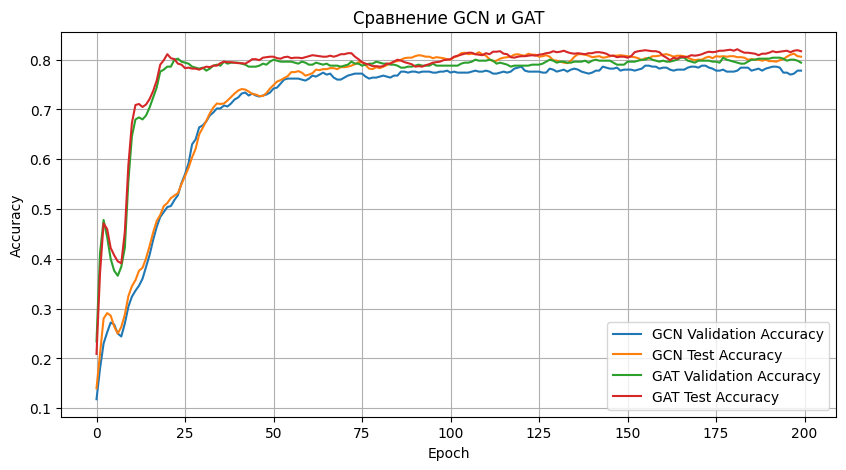

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(gcn_history["val_accuracies"], label="GCN Validation Accuracy")
plt.plot(gcn_history["test_accuracies"], label="GCN Test Accuracy")
plt.plot(gat_history["val_accuracies"], label="GAT Validation Accuracy")
plt.plot(gat_history["test_accuracies"], label="GAT Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Сравнение GCN и GAT")
plt.grid(True)
plt.legend()
plt.show()

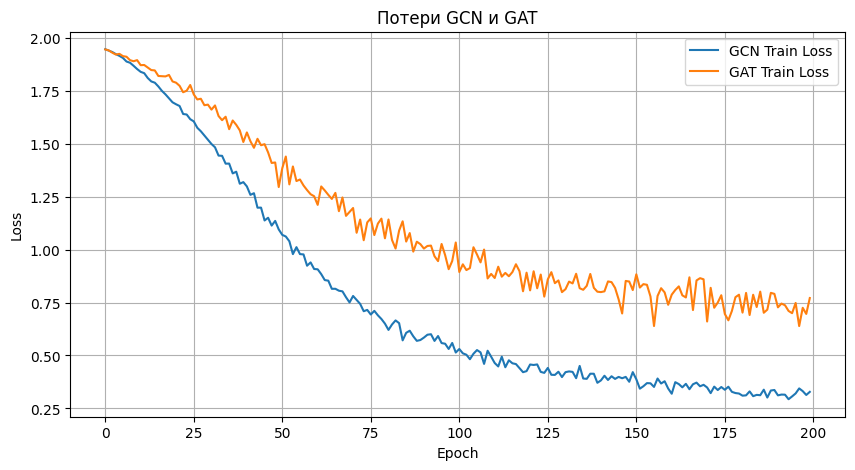

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(gcn_history["train_losses"], label="GCN Train Loss")
plt.plot(gat_history["train_losses"], label="GAT Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Потери GCN и GAT")
plt.grid(True)
plt.legend()
plt.show()

In [13]:
gat_model.eval()
with torch.no_grad():
    _, gat_embeddings = gat_model(data.x, data.edge_index, return_embeddings=True)

gat_embeddings = gat_embeddings.detach().cpu().numpy()
labels = data.y.detach().cpu().numpy()

print("Embeddings shape:", gat_embeddings.shape)

Embeddings shape: (2708, 64)


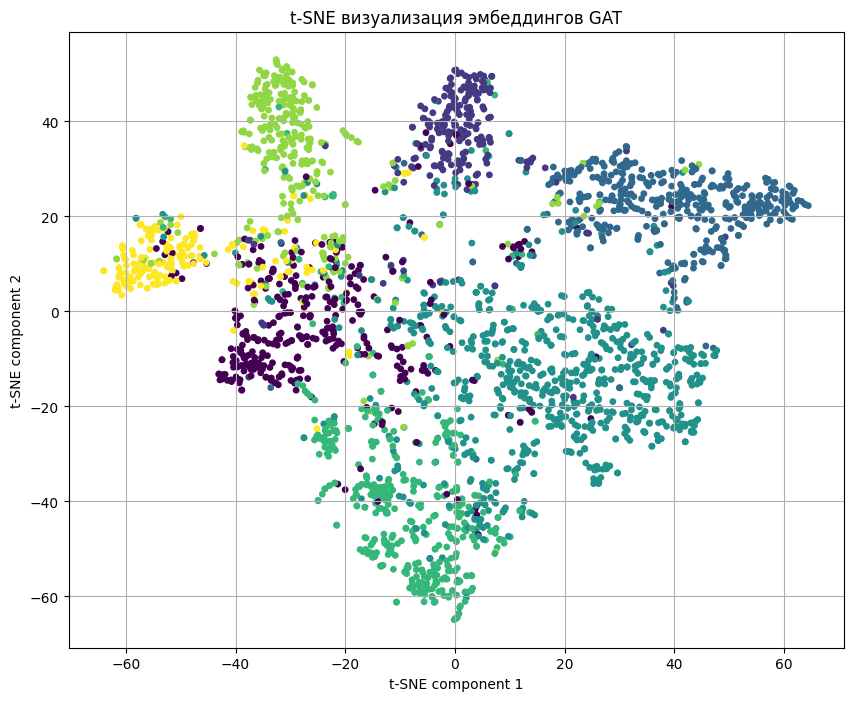

In [14]:
tsne = TSNE(
    n_components=2,
    random_state=SEED,
    init="pca",
    learning_rate="auto",
    perplexity=30
)

gat_emb_2d = tsne.fit_transform(gat_embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    gat_emb_2d[:, 0],
    gat_emb_2d[:, 1],
    c=labels,
    s=15
)
plt.title("t-SNE визуализация эмбеддингов GAT")
plt.xlabel("t-SNE component 1")
plt.ylabel("t-SNE component 2")
plt.grid(True)
plt.show()

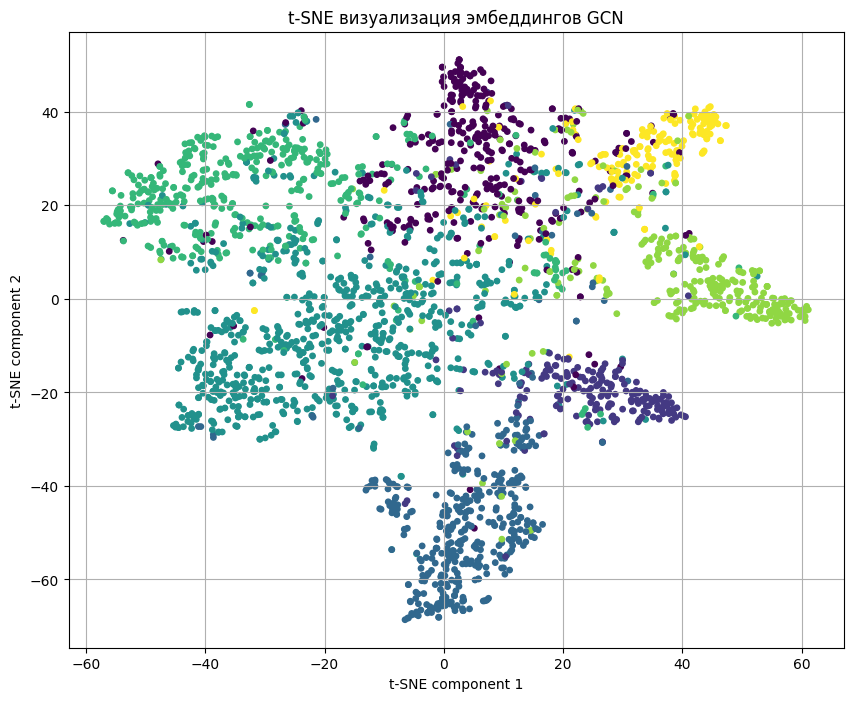

In [15]:
gcn_model.eval()
with torch.no_grad():
    _, gcn_embeddings = gcn_model(data.x, data.edge_index, return_embeddings=True)

gcn_embeddings = gcn_embeddings.detach().cpu().numpy()

tsne_gcn = TSNE(
    n_components=2,
    random_state=SEED,
    init="pca",
    learning_rate="auto",
    perplexity=30
)

gcn_emb_2d = tsne_gcn.fit_transform(gcn_embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(
    gcn_emb_2d[:, 0],
    gcn_emb_2d[:, 1],
    c=labels,
    s=15
)
plt.title("t-SNE визуализация эмбеддингов GCN")
plt.xlabel("t-SNE component 1")
plt.ylabel("t-SNE component 2")
plt.grid(True)
plt.show()

In [16]:
heads_list = [1, 2, 4, 8]
heads_results = {}

for heads in heads_list:
    print(f"\nTraining GAT with heads = {heads}")

    model_heads = GAT(
        in_channels=dataset.num_features,
        hidden_channels=8,
        out_channels=dataset.num_classes,
        heads=heads,
        dropout=0.6
    ).to(device)

    model_heads, history_heads = fit_model(
        model_heads,
        data,
        num_epochs=200,
        lr=0.005,
        weight_decay=5e-4,
        verbose=False
    )

    heads_results[heads] = history_heads["final_test_acc"]
    print(f"Heads = {heads} | Test Accuracy = {history_heads['final_test_acc']:.4f}")


Training GAT with heads = 1
Heads = 1 | Test Accuracy = 0.8060

Training GAT with heads = 2
Heads = 2 | Test Accuracy = 0.8220

Training GAT with heads = 4
Heads = 4 | Test Accuracy = 0.8150

Training GAT with heads = 8
Heads = 8 | Test Accuracy = 0.8290


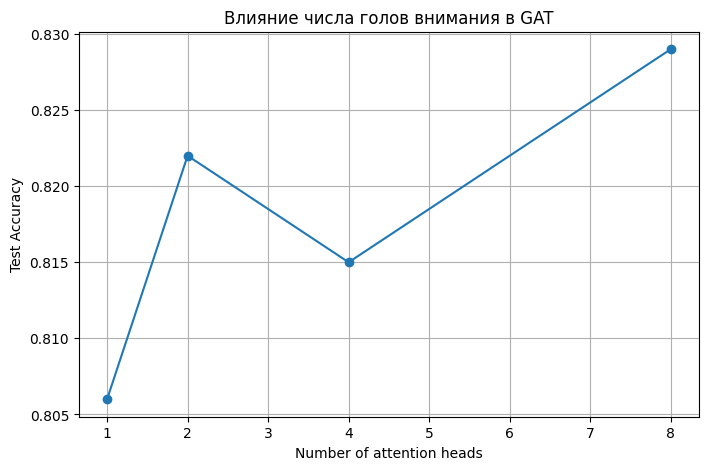

In [17]:
heads_values = list(heads_results.keys())
acc_values = list(heads_results.values())

plt.figure(figsize=(8, 5))
plt.plot(heads_values, acc_values, marker="o")
plt.xlabel("Number of attention heads")
plt.ylabel("Test Accuracy")
plt.title("Влияние числа голов внимания в GAT")
plt.grid(True)
plt.show()

In [18]:
y_true_test = data.y[data.test_mask].detach().cpu().numpy()
y_pred_test = gat_history["pred"][data.test_mask].detach().cpu().numpy()

print("Classification Report (GAT, test):")
print(classification_report(y_true_test, y_pred_test, digits=4))

Classification Report (GAT, test):
              precision    recall  f1-score   support

           0     0.6442    0.8077    0.7167       130
           1     0.8125    0.8571    0.8342        91
           2     0.8912    0.9097    0.9003       144
           3     0.9151    0.7774    0.8407       319
           4     0.7853    0.8591    0.8205       149
           5     0.8587    0.7670    0.8103       103
           6     0.7206    0.7656    0.7424        64

    accuracy                         0.8180      1000
   macro avg     0.8039    0.8205    0.8093      1000
weighted avg     0.8295    0.8180    0.8201      1000



In [20]:
X = data.x.detach().cpu().numpy()
y = data.y.detach().cpu().numpy()

train_mask = data.train_mask.detach().cpu().numpy()
test_mask = data.test_mask.detach().cpu().numpy()

X_train = X[train_mask]
y_train = y[train_mask]
X_test = X[test_mask]
y_test = y[test_mask]

clf = LogisticRegression(
    max_iter=2000,
    random_state=SEED
)

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

lr_test_acc = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression Test Accuracy: {lr_test_acc:.4f}")
print(f"GCN Test Accuracy:                 {gcn_history['final_test_acc']:.4f}")
print(f"GAT Test Accuracy:                 {gat_history['final_test_acc']:.4f}")

Logistic Regression Test Accuracy: 0.5740
GCN Test Accuracy:                 0.8030
GAT Test Accuracy:                 0.8180
